In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import scipy as sp
from scipy import stats
import yaml

In [3]:
from caa_model.config import *
from caa_model.models import base_model, disp_classic, sisp_constrained, disp_staggered
from caa_model.models.disp_classic import DISPClassicDDM
from caa_model.models.sisp_constrained import SISPConstrainedDDM
from caa_model.models.disp_staggered import DISPStaggeredDDM

data = base_model.DATA

## DISP Classic

In [18]:
disp_model = DISPClassicDDM(nr_threads=1)

# Optimize over entire data
# caa_opt = disp_model.fit_global(disp_classic.param_bounds, nr_workers=7, use_chisq=False)
# params_est = DISPClassicDDM.Params(*caa_opt.x)

# params_est = DISPClassicDDM.Params(
#     c=0.998,
#     mu_r=0.002,
#     mu_f=0.306,
#     d_r=0.004,
#     d_f=0.374,
#     tc_bound=0.059,
#     r_bound=0.001,
#     z0=-0.131,
#     mu_r_new=-0.014,
#     mu_f_new=-0.244,
#     t_post=0.586,
#     t0=0.513,
# )

# Attempt 1
# use_chisq = False
# params_est = DISPClassicDDM.Params(
#     c=np.float64(0.9738492885449823),
#     mu_r=np.float64(0.0012050716886431445),
#     mu_f=np.float64(0.25809169048796043),
#     d_r=np.float64(0.0047897330681455075),
#     d_f=np.float64(0.35780822248610056),
#     tc_bound=np.float64(0.07294477415377554),
#     r_bound=np.float64(0.005056833822110751),
#     z0=np.float64(-0.0940878253103078),
#     mu_r_new=np.float64(-0.018425618427557078),
#     mu_f_new=np.float64(-0.3082817505046702),
#     t_post=np.float64(0.5698754014469395),
#     t0=np.float64(0.4967697337548459),
# )

# Attempt 2
params_est = DISPClassicDDM.Params(
    c=np.float64(0.9839469423322917),
    mu_r=np.float64(-0.05222397104655574),
    mu_f=np.float64(0.334658894406465),
    d_r=np.float64(0.10982475171405692),
    d_f=np.float64(0.2812199313586414),
    tc_bound=np.float64(0.057067129956417106),
    r_bound=np.float64(0.06371382016083388),
    z0=np.float64(-0.11009050559487588),
    mu_r_new=np.float64(-0.20676990609747348),
    mu_f_new=np.float64(-0.08936275590665232),
    t_post=np.float64(0.5646556857397613),
    t0=np.float64(0.4896501191177717),
)

params_target, params_lure = DISPClassicDDM.split_params(params_est)

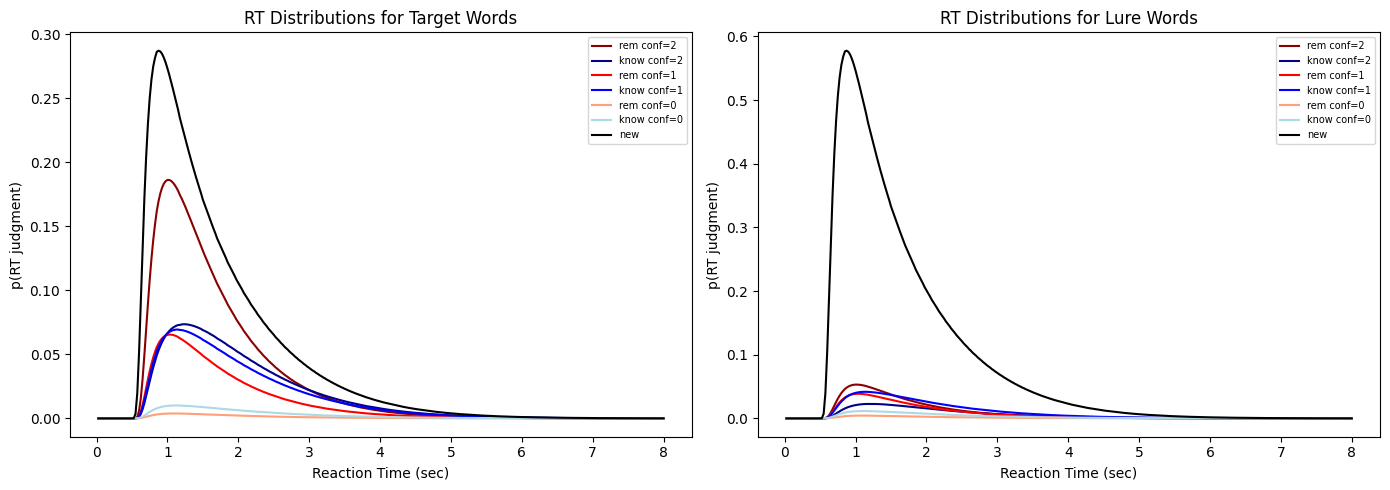

In [19]:
p_rem, p_know, p_new, t = disp_model.predicted_proportions(params_target)
p_rem_lures, p_know_lures, p_new_lures, t = disp_model.predicted_proportions(params_lure)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

confidence_labels = ["conf=2", "conf=1", "conf=0"]
colors_rem = ["darkred", "red", "lightsalmon"]
colors_know = ["darkblue", "blue", "lightblue"]

for i in range(3):
    axes[0].plot(t, p_rem[i] / disp_model.config.delta_t, color=colors_rem[i], label=f"rem {confidence_labels[i]}")
    axes[0].plot(t, p_know[i] / disp_model.config.delta_t, color=colors_know[i], label=f"know {confidence_labels[i]}")
axes[0].plot(t, p_new / disp_model.config.delta_t, color="black", label="new")
axes[0].set_title("RT Distributions for Target Words")
axes[0].set_xlabel("Reaction Time (sec)")
axes[0].set_ylabel("p(RT judgment)")
axes[0].legend(fontsize=7)

for i in range(3):
    axes[1].plot(t, p_rem_lures[i] / disp_model.config.delta_t, color=colors_rem[i], label=f"rem {confidence_labels[i]}")
    axes[1].plot(t, p_know_lures[i] / disp_model.config.delta_t, color=colors_know[i], label=f"know {confidence_labels[i]}")
axes[1].plot(t, p_new_lures / disp_model.config.delta_t, color="black", label="new")
axes[1].set_title("RT Distributions for Lure Words")
axes[1].set_xlabel("Reaction Time (sec)")
axes[1].set_ylabel("p(RT judgment)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [20]:
neg_log_lik = disp_model.compute_gof_all(params_est, use_chisq=False)
n_params = len(params_est)
n_data = (
    len(data.rem_hit.rt)
    + len(data.know_hit.rt)
    + len(data.CR.rt)
    + len(data.miss.rt)
    + len(data.rem_fa.rt)
    + len(data.know_fa.rt)
)

print(f"N data points: {n_data}")

AIC = 2 * n_params + 2 * neg_log_lik
BIC = n_params * np.log(n_data) + 2 * neg_log_lik

print(f"Negative log likelihood: {neg_log_lik:.2f}")
print(f"AIC: {AIC:.0f}")
print(f"BIC: {BIC:.0f}")

N data points: 7735
Negative log likelihood: 790.95
AIC: 1606
BIC: 1689


## SISP Constrained

In [19]:
sisp_model = SISPConstrainedDDM(nr_threads=1)

# Optimize over entire data
# caa_opt = sisp_model.fit_global(sisp_constrained.param_bounds, nr_workers=7, use_chisq=False)
# params_est = SISPConstrainedDDM.Params(*caa_opt.x)

# use_chisq = True
# params_est = SISPConstrainedDDM.Params(
#     1.7802366345277048,
#     1.0732968669582117,
#     0.17804995041166943,
#     0.5326415575619126,
#     0.043589790458315514,
#     0.9574460424899932,
#     -0.690027580392909,
#     -0.565893039286282,
#     1.5546604244949078,
#     0.12666843828878627,
#     0.46706560655302104,
# )

# use_chisq = False
params_est = SISPConstrainedDDM.Params(
    c=np.float64(0.7801720218661342),
    mu_t=np.float64(0.0014979098410432545),
    mu_l=np.float64(0.00370279119459338),
    d=np.float64(0.3272418920383596),
    tc_bound=np.float64(0.199389361806869),
    r_bound_offset=np.float64(0.8539639746606412),
    z0_t=np.float64(0.14429099694980163),
    z0_l=np.float64(-0.3057233602542755),
    t_post=np.float64(0.35812500396288627),
    sigma_z0=np.float64(0.00872676895615948),
    t0=np.float64(0.4990057155454194),
)


params_target, params_lure = SISPConstrainedDDM.split_params(params_est)

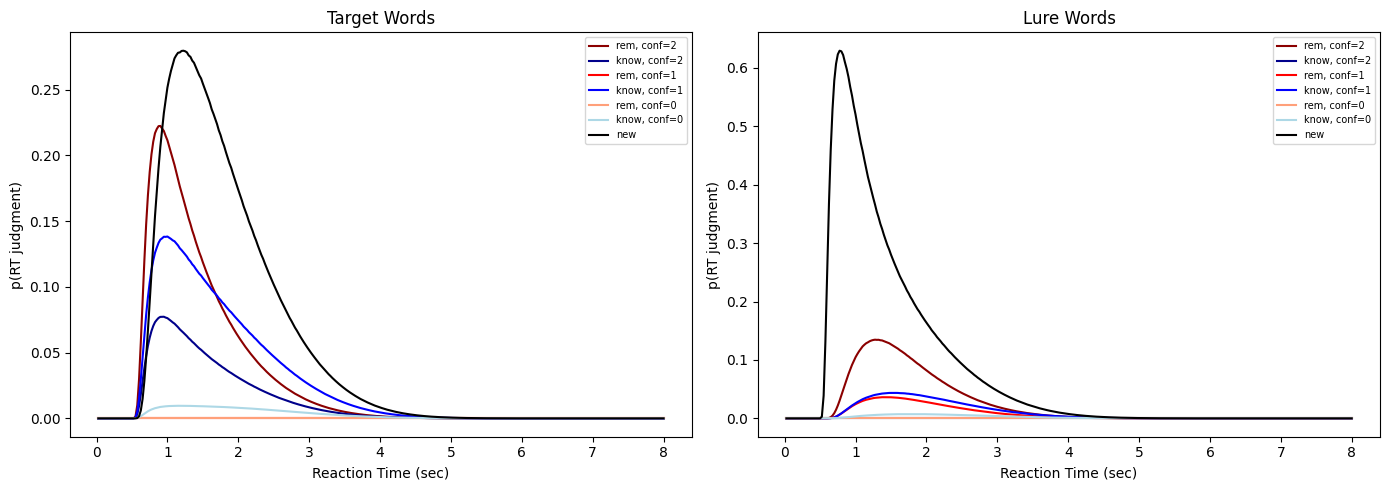

In [20]:
p_rem_t, p_know_t, p_new_t, t_t = sisp_model.predicted_proportions(params_target)
p_rem_l, p_know_l, p_new_l, t_l = sisp_model.predicted_proportions(params_lure)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confidence_labels = ["conf=2", "conf=1", "conf=0"]
colors_rem = ["darkred", "red", "lightsalmon"]
colors_know = ["darkblue", "blue", "lightblue"]

for i in range(3):
    axes[0].plot(
        t_t, p_rem_t[i] / sisp_model.config.delta_t, color=colors_rem[i], label=f"rem, {confidence_labels[i]}"
    )
    axes[0].plot(
        t_t, p_know_t[i] / sisp_model.config.delta_t, color=colors_know[i], label=f"know, {confidence_labels[i]}"
    )
axes[0].plot(t_t, p_new_t / sisp_model.config.delta_t, color="black", label="new")
axes[0].set_title("Target Words")
axes[0].set_xlabel("Reaction Time (sec)")
axes[0].set_ylabel("p(RT judgment)")
axes[0].legend(fontsize=7)

for i in range(3):
    axes[1].plot(
        t_l, p_rem_l[i] / sisp_model.config.delta_t, color=colors_rem[i], label=f"rem, {confidence_labels[i]}"
    )
    axes[1].plot(
        t_l, p_know_l[i] / sisp_model.config.delta_t, color=colors_know[i], label=f"know, {confidence_labels[i]}"
    )
axes[1].plot(t_l, p_new_l / sisp_model.config.delta_t, color="black", label="new")
axes[1].set_title("Lure Words")
axes[1].set_xlabel("Reaction Time (sec)")
axes[1].set_ylabel("p(RT judgment)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [22]:
neg_log_lik = sisp_model.compute_gof_all(params_est, use_chisq=False)
n_params = len(params_est)
n_data = (
    len(data.rem_hit.rt)
    + len(data.know_hit.rt)
    + len(data.CR.rt)
    + len(data.miss.rt)
    + len(data.rem_fa.rt)
    + len(data.know_fa.rt)
)

print(f"N data points: {n_data}")

AIC = 2 * n_params + 2 * neg_log_lik
BIC = n_params * np.log(n_data) + 2 * neg_log_lik

print(f"Negative log likelihood: {neg_log_lik:.2f}")
print(f"AIC: {AIC:.0f}")
print(f"BIC: {BIC:.0f}")

N data points: 7735
Negative log likelihood: 14569.91
AIC: 29162
BIC: 29238


## DISP Staggered

In [ ]:
disp_staggered_model = DISPStaggeredDDM(nr_threads=1)

# Optimize over entire data
# caa_opt = disp_staggered_model.fit_global(disp_staggered.param_bounds, nr_workers=7, use_chisq=False)
# params_est = DISPStaggeredDDM.Params(*caa_opt.x)

# Attempt 1
# use_chisq = False
# params_est = DISPStaggeredDDM.Params(
#     c=np.float64(0.9991464160682735),
#     mu_r=np.float64(0.009673878381526002),
#     mu_f=np.float64(0.25086479036645715),
#     d_r=np.float64(0.005115150485063391),
#     d_f=np.float64(0.38140642178095474),
#     tc_bound=np.float64(0.05190842289428749),
#     r_bound=np.float64(0.006080488321965394),
#     z0=np.float64(-0.11966264331073584),
#     z0_new=np.float64(-0.12539525069798851),
#     mu_r_new=np.float64(-0.020268445090337872),
#     mu_f_new=np.float64(-0.28106030203277155),
#     t_post=np.float64(0.5643891315178502),
#     t_delay_r=np.float64(0.39317873130193737),
#     t0=np.float64(0.49643344225052194),
# )

# Attempt 2
# params_est = DISPStaggeredDDM.Params(
#     c=np.float64(0.9888728634923241),
#     mu_r=np.float64(-0.12839564074460696),
#     mu_f=np.float64(0.3996328018768467),
#     d_r=np.float64(0.1719752915151087),
#     d_f=np.float64(0.24874770127991175),
#     tc_bound=np.float64(0.05082384736309309),
#     r_bound=np.float64(0.003134022101775824),
#     z0=np.float64(-0.14320294173029124),
#     z0_new=np.float64(-0.2014018927603651),
#     mu_r_new=np.float64(-0.35894325697436136),
#     mu_f_new=np.float64(0.05934895315873234),
#     t_post=np.float64(0.5031689498966928),
#     t_delay_r=np.float64(0.2145299979025289),
#     t0=np.float64(0.4947368451924701),
# )

# Attempt 3
params_est = DISPStaggeredDDM.Params(
    c=np.float64(0.9944747531085043),
    mu_r=np.float64(-0.09936966164007344),
    mu_f=np.float64(0.38569509914634637),
    d_r=np.float64(0.15453404227056255),
    d_f=np.float64(0.27144602850053545),
    tc_bound=np.float64(0.051699912298099504),
    r_bound=np.float64(0.006973033435801135),
    z0=np.float64(-0.12890907740414018),
    z0_new=np.float64(-0.2345484654891833),
    mu_r_new=np.float64(-0.3415451801281406),
    mu_f_new=np.float64(0.048392928941960456),
    t_post=np.float64(0.4824138548171153),
    t_delay_r=np.float64(0.23079148715627928),
    t0=np.float64(0.4985948017976732),
)

params_target, params_lure = DISPStaggeredDDM.split_params(params_est)

differential_evolution step 1: f(x)= 7311.730240256473
differential_evolution step 2: f(x)= 5157.434840356918
differential_evolution step 3: f(x)= 2860.9712353214327
differential_evolution step 4: f(x)= 2860.9712353214327
differential_evolution step 5: f(x)= 2860.9712353214327
differential_evolution step 6: f(x)= 2860.9712353214327
differential_evolution step 7: f(x)= 2860.9712353214327
differential_evolution step 8: f(x)= 2860.9712353214327
differential_evolution step 9: f(x)= 2860.9712353214327
differential_evolution step 10: f(x)= 2579.6021051542684
differential_evolution step 11: f(x)= 2388.3185190921267
differential_evolution step 12: f(x)= 1867.0170812936485
differential_evolution step 13: f(x)= 1867.0170812936485
differential_evolution step 14: f(x)= 1867.0170812936485
differential_evolution step 15: f(x)= 1867.0170812936485
differential_evolution step 16: f(x)= 1867.0170812936485
differential_evolution step 17: f(x)= 1867.0170812936485
differential_evolution step 18: f(x)= 1867

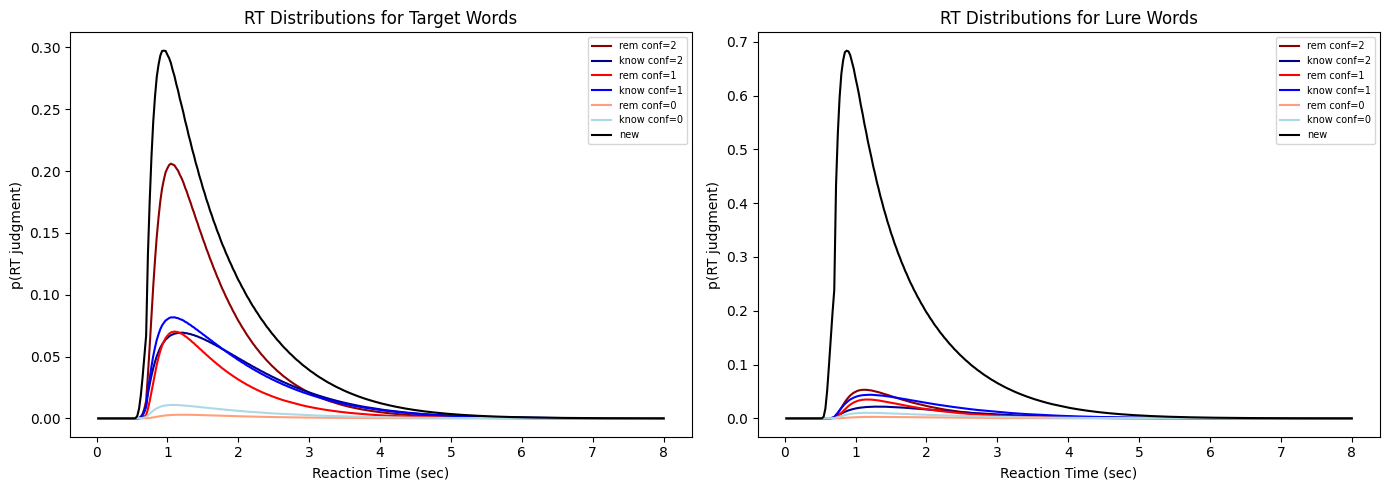

In [29]:
p_rem, p_know, p_new, t = disp_staggered_model.predicted_proportions(params_target)
p_rem_lures, p_know_lures, p_new_lures, t = disp_staggered_model.predicted_proportions(params_lure)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

confidence_labels = ["conf=2", "conf=1", "conf=0"]
colors_rem = ["darkred", "red", "lightsalmon"]
colors_know = ["darkblue", "blue", "lightblue"]

for i in range(3):
    axes[0].plot(t, p_rem[i] / disp_staggered_model.config.delta_t, color=colors_rem[i], label=f"rem {confidence_labels[i]}")
    axes[0].plot(t, p_know[i] / disp_staggered_model.config.delta_t, color=colors_know[i], label=f"know {confidence_labels[i]}")
axes[0].plot(t, p_new / disp_staggered_model.config.delta_t, color="black", label="new")
axes[0].set_title("RT Distributions for Target Words")
axes[0].set_xlabel("Reaction Time (sec)")
axes[0].set_ylabel("p(RT judgment)")
axes[0].legend(fontsize=7)

for i in range(3):
    axes[1].plot(t, p_rem_lures[i] / disp_staggered_model.config.delta_t, color=colors_rem[i], label=f"rem {confidence_labels[i]}")
    axes[1].plot(t, p_know_lures[i] / disp_staggered_model.config.delta_t, color=colors_know[i], label=f"know {confidence_labels[i]}")
axes[1].plot(t, p_new_lures / disp_staggered_model.config.delta_t, color="black", label="new")
axes[1].set_title("RT Distributions for Lure Words")
axes[1].set_xlabel("Reaction Time (sec)")
axes[1].set_ylabel("p(RT judgment)")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [26]:
neg_log_lik = disp_staggered_model.compute_gof_all(params_est, use_chisq=False)
n_params = len(params_est)
n_data = (
    len(data.rem_hit.rt)
    + len(data.know_hit.rt)
    + len(data.CR.rt)
    + len(data.miss.rt)
    + len(data.rem_fa.rt)
    + len(data.know_fa.rt)
)

print(f"N data points: {n_data}")

AIC = 2 * n_params + 2 * neg_log_lik
BIC = n_params * np.log(n_data) + 2 * neg_log_lik

print(f"Negative log likelihood: {neg_log_lik:.2f}")
print(f"AIC: {AIC:.0f}")
print(f"BIC: {BIC:.0f}")

N data points: 7735
Negative log likelihood: 706.36
AIC: 1441
BIC: 1538


## Actual RT

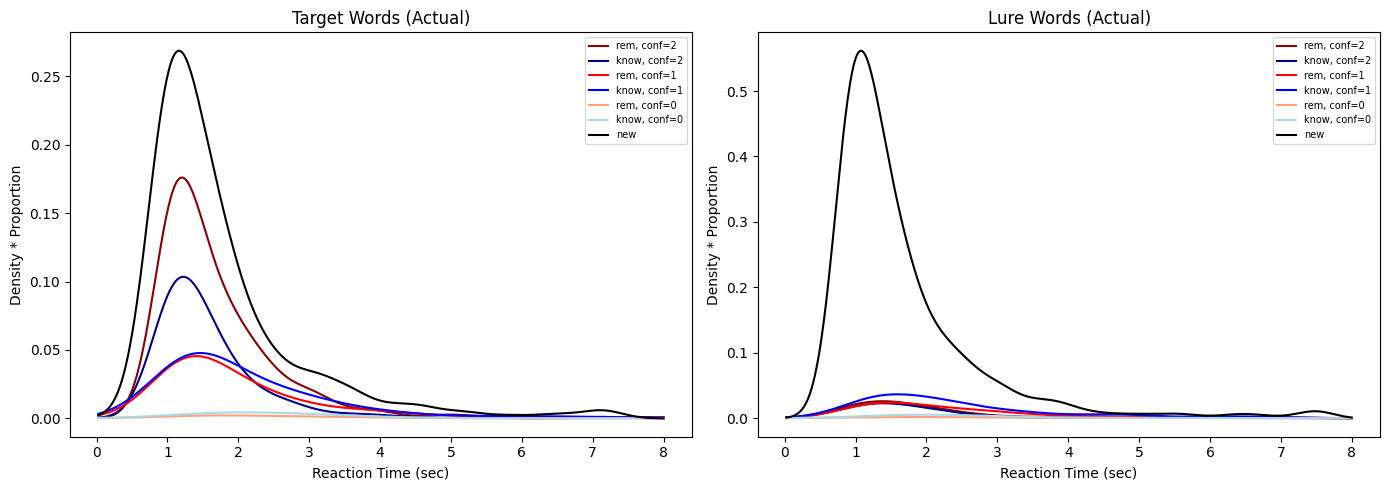

In [28]:
# Calculate total N for Targets and Lures to normalize the densities
N_target = len(data.rem_hit.rt) + len(data.know_hit.rt) + len(data.miss.rt)
N_lure = len(data.rem_fa.rt) + len(data.know_fa.rt) + len(data.CR.rt)

# Create a time axis for the KDE matching your model's maximum time
t_eval = np.linspace(CAA_CFG.delta_t, CAA_CFG.max_t, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confidence_labels = ["conf=2", "conf=1", "conf=0"]

# We map the loop index to the actual confidence ratings in the data (2, 1, 0)
conf_vals = [2, 1, 0] 

colors_rem = ["darkred", "red", "lightsalmon"]
colors_know = ["darkblue", "blue", "lightblue"]

def plot_empirical_kde(ax, rt_data, total_N, color, label):
    """Generates a KDE for the RTs and scales it by its proportion of total trials."""
    if len(rt_data) > 1: # KDE requires at least a few data points
        try:
            kde = stats.gaussian_kde(rt_data)
            # Scale the density curve by the relative frequency of this response
            scaled_density = kde(t_eval) * (len(rt_data) / total_N)
            ax.plot(t_eval, scaled_density, color=color, label=label)
        except np.linalg.LinAlgError:
            pass # Skips plotting if there is zero variance in the small bin

# --- Target Words (Empirical) ---
for i, conf_val in enumerate(conf_vals):
    # Remember Hits
    rt_subset_rem = data.rem_hit.rt[data.rem_hit.conf == conf_val]
    plot_empirical_kde(axes[0], rt_subset_rem, N_target, colors_rem[i], f"rem, {confidence_labels[i]}")
    
    # Know Hits
    rt_subset_know = data.know_hit.rt[data.know_hit.conf == conf_val]
    plot_empirical_kde(axes[0], rt_subset_know, N_target, colors_know[i], f"know, {confidence_labels[i]}")

# Misses (Actual "New" responses to Targets)
plot_empirical_kde(axes[0], data.miss.rt, N_target, "black", "new")

axes[0].set_title("Target Words (Actual)")
axes[0].set_xlabel("Reaction Time (sec)")
axes[0].set_ylabel("Density * Proportion")
axes[0].legend(fontsize=7)

# --- Lure Words (Empirical) ---
for i, conf_val in enumerate(conf_vals):
    # Remember False Alarms
    rt_subset_rem = data.rem_fa.rt[data.rem_fa.conf == conf_val]
    plot_empirical_kde(axes[1], rt_subset_rem, N_lure, colors_rem[i], f"rem, {confidence_labels[i]}")
    
    # Know False Alarms
    rt_subset_know = data.know_fa.rt[data.know_fa.conf == conf_val]
    plot_empirical_kde(axes[1], rt_subset_know, N_lure, colors_know[i], f"know, {confidence_labels[i]}")

# Correct Rejections (Actual "New" responses to Lures)
plot_empirical_kde(axes[1], data.CR.rt, N_lure, "black", "new")

axes[1].set_title("Lure Words (Actual)")
axes[1].set_xlabel("Reaction Time (sec)")
axes[1].set_ylabel("Density * Proportion")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()